In [1]:
from pykawa.cross_sections import CrossSection, CrossSectionInterpolator, make_cross_section_interpolator
from pykawa.utils import get_phases
import numpy as np
import matplotlib.pyplot as plt

In [3]:

cross_section_interpolator,cross_section_table, log10_mass_ratio_values, log10alpha_values, v_grid_table = make_cross_section_interpolator('REPULSIVE_YUKAWA')

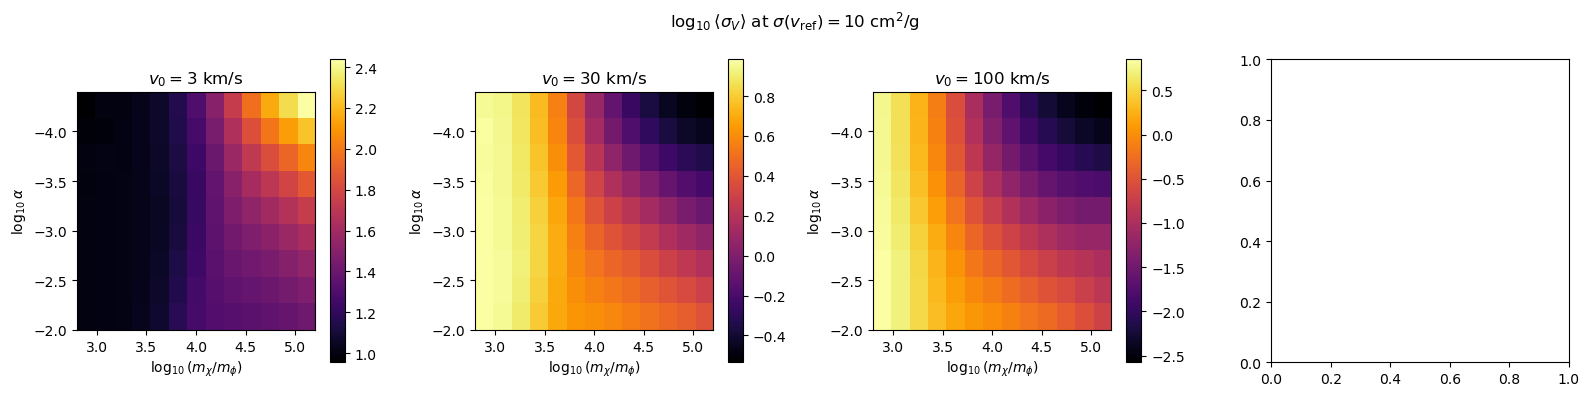

In [6]:
v0_values = [3, 30, 100]
amp_at_vref = 10

ncols = 4
nrows = int(np.ceil(len(v0_values) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, v0 in zip(axes, v0_values):
    sigma_ta = np.empty((len(log10alpha_values), len(log10_mass_ratio_values)))
    for i, log10alpha in enumerate(log10alpha_values):
        for j, log10_mr in enumerate(log10_mass_ratio_values):
            sigma_ta[i, j] = cross_section_interpolator.thermal_average(
                v0, amp_at_vref, log10alpha, log10_mr, use_interp=False)

    extent = [log10_mass_ratio_values[0], log10_mass_ratio_values[-1],
              log10alpha_values[0], log10alpha_values[-1]]
    aspect = np.absolute(log10_mass_ratio_values[-1] - log10_mass_ratio_values[0]) / \
             np.absolute(log10alpha_values[-1] - log10alpha_values[0])
    im = ax.imshow(np.log10(sigma_ta),
                   origin='lower', cmap='inferno',
                   extent=extent, aspect=aspect)
    plt.colorbar(im, ax=ax)
    ax.set_title(r'$v_0 = %d$ km/s' % v0)
    ax.set_xlabel(r'$\log_{10}(m_\chi/m_\phi)$')
    ax.set_ylabel(r'$\log_{10}\alpha$')

plt.suptitle(r'$\log_{10}\langle\sigma_V\rangle$ at $\sigma(v_{\rm ref}) = %d$ cm$^2$/g' % amp_at_vref)
plt.tight_layout()
plt.show()